## Heart Disease Prediction project

---





# Part(1) Import libraries and Load the dataset


In [ ]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt



In [ ]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import kagglehub


/kaggle/input/heart-disease-dataset/heart.csv


In [ ]:
heart_df = pd.read_csv("/kaggle/input/heart-disease-dataset/heart.csv")

In [ ]:
# Display basic information
heart_df.info()

# Show first rows of the dataset
heart_df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
#size of the dataset
heart_df.shape


(1025, 14)

In [ ]:
#Type of the dataset
heart_df.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [ ]:

#statistical summary
heart_df.describe()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


# Part(2)  Check for missing values


In [ ]:
# Check for missing values
print("\nMissing Values\n", heart_df.isnull().sum())

# Check class balance
print("\nTarget Class Distribution (1 = Disease, 0 = Healthy):")
print(heart_df['target'].value_counts())


Missing Values
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Target Class Distribution (1 = Disease, 0 = Healthy):
target
1    526
0    499
Name: count, dtype: int64


# Part(3) Exploratory Data Analysis (EDA)


/tmp/ipykernel_2997/3101475677.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=heart_df ,     palette=['yellow', 'blue']


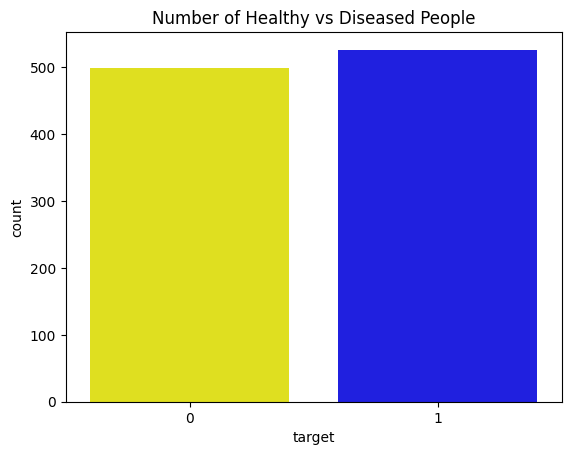

In [ ]:

#Question 1 : How many people are sick and healthy in the dataset?
heart_df['target'].value_counts()
sns.countplot(x='target', data=heart_df ,     palette=['yellow', 'blue'])
plt.title("Number of Healthy vs Diseased People")
plt.show()

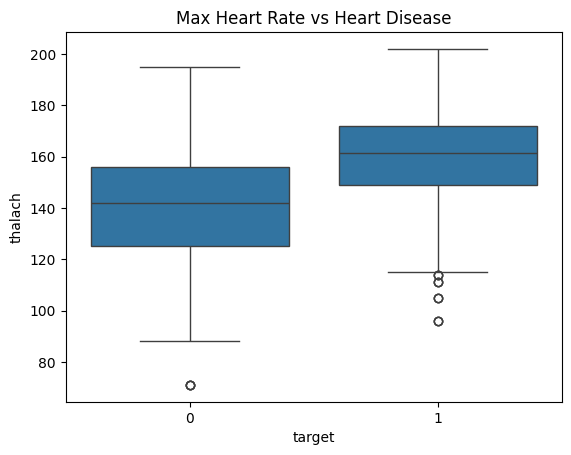

In [ ]:
# Question 2:Is there a difference in the maximum heart rate between people with heart disease and healthy individuals?
sns.boxplot(x='target', y='thalach', data=heart_df)
plt.title("Max Heart Rate vs Heart Disease")
plt.show()

# part(4) Data Preprocessing and Splitting


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define features (X) and target (y)
X = heart_df.drop("target", axis=1)
y = heart_df["target"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train_scaled.shape)
print("Testing set shape:", X_test_scaled.shape)

Training set shape: (820, 13)
Testing set shape: (205, 13)


# part(5) Logistic Regression and Model Evaluation


In [ ]:
# Initialize and train the Logistic Regression model
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = log_model.predict(X_test_scaled)


In [ ]:
# Calculate and print evaluation metrics
print("CLASSIFICATION METRICS ")
print(f"Accuracy:  {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred)*100:.2f}%")
print(f"Recall:    {recall_score(y_test, y_pred)*100:.2f}%")
print(f"F1-Score:  {f1_score(y_test, y_pred)*100:.2f}%\n")


CLASSIFICATION METRICS 
Accuracy:  79.51%
Precision: 75.63%
Recall:    87.38%
F1-Score:  81.08%



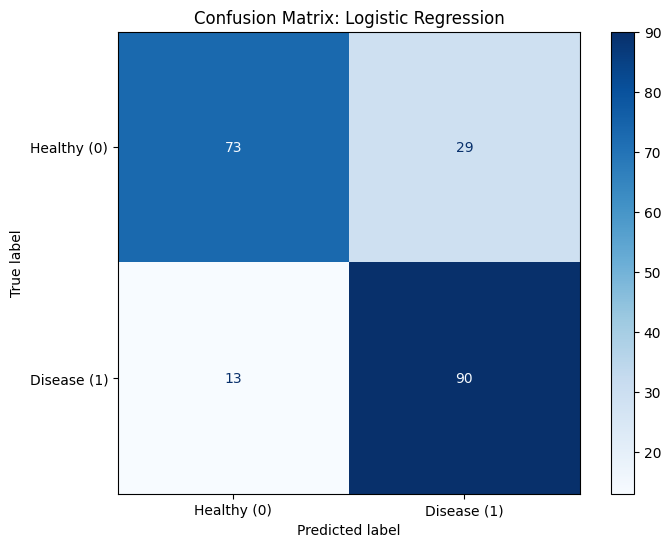

In [ ]:
# Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy (0)", "Disease (1)"])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap="Blues", values_format="d", ax=ax)
plt.title("Confusion Matrix: Logistic Regression")
plt.show()

 METRICS AT 30% THRESHOLD 
Accuracy:  78.54%
Precision: 72.18%
Recall:    93.20%
F1-Score:  81.36%



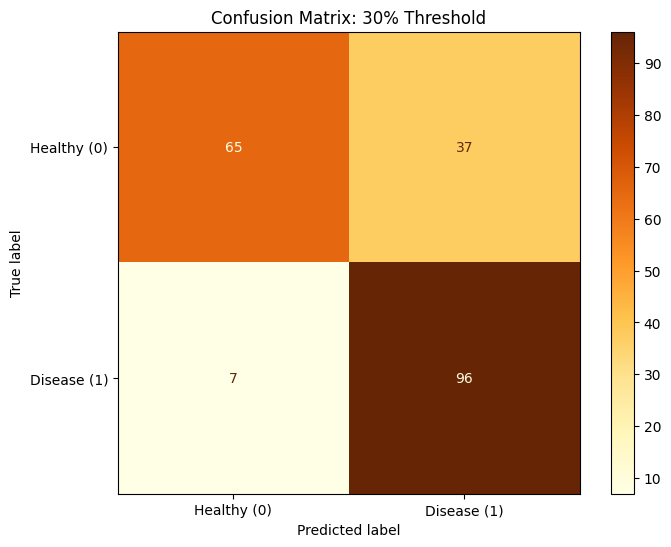

In [ ]:
# Extract probabilities for the positive class (Disease = 1)
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

# Apply a custom lowered threshold of 0.30
custom_threshold = 0.30
y_pred_custom = (y_prob >= custom_threshold).astype(int)

# Calculate and print NEW evaluation metrics
print(" METRICS AT 30% THRESHOLD ")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_custom)*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_custom)*100:.2f}%")
print(f"Recall:    {recall_score(y_test, y_pred_custom)*100:.2f}%")
print(f"F1-Score:  {f1_score(y_test, y_pred_custom)*100:.2f}%\n")

# Plot the NEW Confusion Matrix
cm_custom = confusion_matrix(y_test, y_pred_custom)
disp_custom = ConfusionMatrixDisplay(confusion_matrix=cm_custom, display_labels=["Healthy (0)", "Disease (1)"])

fig, ax = plt.subplots(figsize=(8, 6))
disp_custom.plot(cmap="YlOrBr", values_format="d", ax=ax)
plt.title("Confusion Matrix: 30% Threshold")
plt.show()


*   loaded the Heart Disease dataset for analysis.

*   Exploratory Data Analysis (EDA) to understand data distribution

*   Preprocessed the data by handling features, splitting into training and   testing sets then  applying feature scaling.
* Built a Logistic Regression model and evaluated its performance using Accuracy, Precision, Recall and F1-score.

*   Improved model performance by optimizing the decision threshold









